# Text-to-image Recognition Using odia-ocr-merged dataset (shantipriya/odia-ocr-merge)


In [1]:
import numpy as np
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io

## First Tried records for simplicity and experimentation
10000, 30000, 40000, 50000

In [2]:
# Load only the first 30,000 rows
ds = load_dataset("shantipriya/odia-ocr-merged", split='train[:50000]')

# Convert to Pandas for exploration
odia_df = ds.to_pandas()
print(f"Loaded {len(odia_df)} rows successfully!")


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

Loaded 50000 rows successfully!


In [3]:
odia_df.head()

,text,image
0,ପ୍ରେରଣର,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
1,ଫୁଲି,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
2,ସିମିତ,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
3,ମୈସ୍ଚୁସେଟ୍ସ,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
4,ଜ୍ୱରଜାତ,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...


In [5]:
img_io = io.BytesIO(odia_df["image"][0]["bytes"])
img = Image.open(img_io).convert("L") #converting to grayscale image
pixel_array = np.array(img)

pixel_array

array([[ 82,  82,  77, ...,  54,  55,  58],
       [128, 126, 120, ...,  63,  60,  60],
       [165, 167, 165, ...,  81,  73,  66],
       ...,
       [193, 195, 198, ..., 161, 114,  81],
       [194, 195, 197, ..., 161, 115,  81],
       [191, 192, 194, ..., 159, 112,  79]], dtype=uint8)

In [6]:
pixel_array.shape

(294, 948)

In [7]:
odia_df['text'].value_counts()

text
କାରଣରୂପେ           9
ପ୍ରୋଟିଓଗ୍ଲାଇକାନ    9
ଭାଷାଭାଷୀ           9
ଗଣାଯାଇଥାଏ          9
ଗୁଡ଼ାଇବାକୁ         9
                  ..
ହାଦି               1
ଲେଖିଲେ             1
ଆଖ୍ୟା              1
ବିଶାଖପାଟଣା         1
୧୮୭୫-୧୯୬୮          1
Name: count, Length: 10925, dtype: int64

## Preprocessing Image and Labels

In [3]:
def preprocess_images_labels(df):

    images = []
    labels = []

    for index, row in df.iterrows():

        img_bytes = row["image"]["bytes"]
        img = Image.open(io.BytesIO(img_bytes)).convert("L")# Converting to grayscale image

        img = img.resize((256, 64))

        img = np.array(img)

        images.append(img)
        labels.append(row["text"])

    return images, labels


images, labels = preprocess_images_labels(odia_df)

In [5]:
images[:3]

[array([[147, 155, 154, ..., 100, 107,  94],
        [195, 208, 208, ..., 193, 200, 182],
        [198, 206, 208, ..., 208, 207, 183],
        ...,
        [205, 211, 203, ..., 210, 197, 137],
        [204, 208, 204, ..., 210, 201, 136],
        [196, 202, 203, ..., 206, 201, 134]], dtype=uint8),
 array([[198, 206, 208, ..., 199, 188, 137],
        [197, 205, 208, ..., 201, 188, 130],
        [201, 205, 205, ..., 200, 184, 127],
        ...,
        [202, 201, 205, ..., 172,  96,  62],
        [200, 198, 203, ..., 170,  90,  61],
        [140, 127, 142, ..., 164,  88,  60]], dtype=uint8),
 array([[122, 114, 109, ..., 146, 153, 151],
        [194, 198, 200, ..., 207, 207, 204],
        [207, 208, 207, ..., 206, 204, 206],
        ...,
        [204, 205, 206, ..., 207, 204, 198],
        [199, 203, 207, ..., 202, 202, 201],
        [200, 201, 202, ..., 200, 200, 197]], dtype=uint8)]

ପ୍ରେରଣର


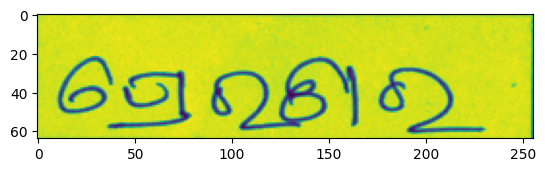

In [4]:
plt.imshow(images[0])
print(labels[0])

In [7]:
labels[:3]

['ପ୍ରେରଣର', 'ଫୁଲି', 'ସିମିତ']

## Splitting the dataset into train/val/test sets

In [4]:
train_size = int(0.8 * len(images))
val_size = int(0.9 * len(images))

X_train = images[:train_size]
y_train = labels[:train_size]

X_val = images[train_size:val_size]
y_val = labels[train_size:val_size]

X_test = images[val_size:]
y_test = labels[val_size:]

In [7]:
print(len(X_train), len(y_train))
print(len(X_val), len(y_val))
print(len(X_test), len(y_test))

40000 40000
5000 5000
5000 5000


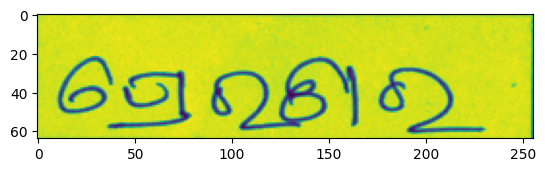

ପ୍ରେରଣର


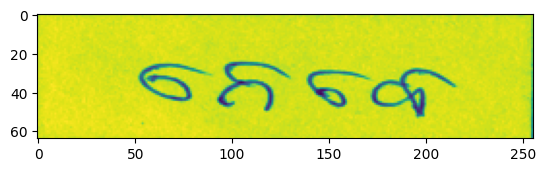

ନେବେ


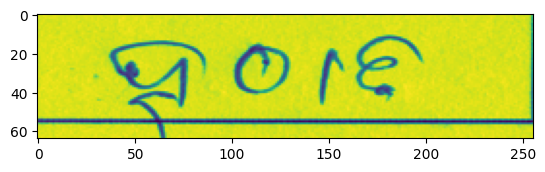

ହଠାତ


In [9]:
plt.imshow(X_train[0])
plt.show()
print(y_train[0])
plt.imshow(X_val[0])
plt.show()
print(y_val[0])
plt.imshow(X_test[0])
plt.show()
print(y_test[0])

## Model Building and Training with Sequential

In [6]:
# Library Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
import keras

## Vocabolary Build

In [7]:
all_text = "".join(labels)

vocab = sorted(set(all_text))

num_chars = len(vocab)

print("Vocab size:", num_chars)
print(vocab)

Vocab size: 84
['-', '।', 'ଁ', 'ଂ', 'ଃ', 'ଅ', 'ଆ', 'ଇ', 'ଈ', 'ଉ', 'ଊ', 'ଋ', 'ଏ', 'ଐ', 'ଓ', 'ଔ', 'କ', 'ଖ', 'ଗ', 'ଘ', 'ଙ', 'ଚ', 'ଛ', 'ଜ', 'ଝ', 'ଞ', 'ଟ', 'ଠ', 'ଡ', 'ଢ', 'ଣ', 'ତ', 'ଥ', 'ଦ', 'ଧ', 'ନ', 'ପ', 'ଫ', 'ବ', 'ଭ', 'ମ', 'ଯ', 'ର', 'ଲ', 'ଳ', 'ଵ', 'ଶ', 'ଷ', 'ସ', 'ହ', '଼', 'ା', 'ି', 'ୀ', 'ୁ', 'ୂ', 'ୃ', 'ୄ', 'େ', 'ୈ', 'ୋ', 'ୌ', '୍', 'ୖ', 'ୗ', 'ଡ଼', 'ଢ଼', 'ୟ', 'ୠ', 'ୡ', 'ୢ', 'ୣ', '୦', '୧', '୨', '୩', '୪', '୫', '୬', '୭', '୮', '୯', '୰', 'ୱ']


## Character Encoding

In [8]:
import tensorflow as tf

char_to_num = tf.keras.layers.StringLookup(
    vocabulary=vocab,
    mask_token=None
)

num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(),
    mask_token=None,
    invert=True
)

I0000 00:00:1773146296.005325     734 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Converting Image to tensors

In [9]:
X_train = np.array(X_train)[..., np.newaxis]
X_val = np.array(X_val)[..., np.newaxis]
X_test = np.array(X_test)[..., np.newaxis]

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

ପ୍ରେରଣର


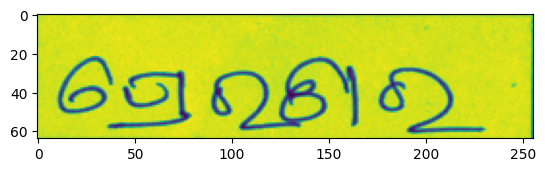

In [15]:
plt.imshow(X_train[0])
print(y_train[0])

## Labels Encoding

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_label_length = 32

def encode_labels(labels):

    encoded = []

    for label in labels:

        chars = tf.strings.unicode_split(label, "UTF-8")

        nums = char_to_num(chars)

        nums = nums - 1 # doing this because there is mapping error occured

        encoded.append(nums.numpy())

    padded = pad_sequences(
        encoded,
        maxlen=max_label_length,
        padding="post",
        value=-1
    )

    return padded


y_train = encode_labels(y_train)
y_val = encode_labels(y_val)
y_test = encode_labels(y_test)

In [18]:
# Finding the max word length
max_label_length = max(len(label) for label in labels)

print("Max label length:", max_label_length)

Max label length: 29


## Build CRNN model
with keras functional API

In [11]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

input_img = layers.Input(shape=(64,256,1), name="image")

x = layers.Rescaling(1./255)(input_img)

x = layers.Conv2D(64,3,padding="same",activation="relu")(x)
x = layers.MaxPool2D((2,2))(x)

x = layers.Conv2D(128,3,padding="same",activation="relu")(x)
x = layers.MaxPool2D((2,2))(x)

x = layers.Conv2D(256,3,padding="same",activation="relu")(x)
x = layers.MaxPool2D((2,2))(x)

# convert feature map to sequence
x = layers.Permute((2,1,3))(x)

x = layers.Reshape((32, 8*256))(x)

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True)
)(x)

output = layers.Dense(num_chars + 1, activation="softmax")(x)

model = Model(inputs=input_img, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 32, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 32, 8, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │     2,229,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32, 85)         │        21,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,757 (10.00 MB)

 Trainable params: 2,620,757 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

## CTC Loss function

In [12]:
def ctc_loss(y_true, y_pred):

    batch_len = tf.shape(y_true)[0]

    input_length = tf.fill([batch_len,1], tf.shape(y_pred)[1])

    label_length = tf.math.count_nonzero(
        y_true != -1,
        axis=1,
        keepdims=True
    )

    y_true = tf.where(y_true == -1,
                      tf.zeros_like(y_true),
                      y_true)
    loss = tf.keras.backend.ctc_batch_cost(
        y_true,
        y_pred,
        input_length,
        label_length
    )

    return loss

## Compile the model

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=ctc_loss,
    metrics=["accuracy"]
)

## Training and Early Stop

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/100


I0000 00:00:1773146927.917993     816 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.0000e+00 - loss: 46.3111 - val_accuracy: 0.0000e+00 - val_loss: 27.1134
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 2.2434e-04 - loss: 27.0210 - val_accuracy: 0.0031 - val_loss: 26.6649
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.0030 - loss: 26.6981 - val_accuracy: 0.0030 - val_loss: 26.4841
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.0030 - loss: 26.5014 - val_accuracy: 0.0030 - val_loss: 26.3893
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.0030 - loss: 26.4646 - val_accuracy: 0.0028 - val_loss: 26.3460
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.0030 - loss: 26.4565 - val_accuracy: 0.0030 - val_loss: 26.2827
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.0030 - loss: 26.2757 - val_accuracy: 0.0031 - val_loss: 26.2605
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.

## Function for Decoding the prediction and labels

In [32]:
def decode_prediction(pred_indices):
    # Shift it back up to get the correct character mapping
    original_indices = pred_indices + 1
    
    # 2. Map and join
    chars = num_to_char(original_indices)
    text = tf.strings.reduce_join(chars).numpy().decode("utf-8")
    
    # 3. Strip any [UNK] that appear due to model uncertainty or padding
    return text.replace("[UNK]", "")

In [33]:
def decode_label(label):
    # 1. Filter out the padding (-1)
    label = label[label != -1]
    
    # 2. IMPORTANT: Shift back (+ 1) to match your original vocabulary
    label = label + 1
    
    # 3. Map to characters
    chars = num_to_char(label)
    
    # 4. Join and decode
    return tf.strings.reduce_join(chars).numpy().decode("utf-8")


### Model evaluation

In [39]:
model.evaluate(X_test, y_test) # Loss and Accuracy

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.0373 - loss: 17.2585


[17.40401840209961, 0.03671250119805336]

## Model Prediction

In [34]:
pred = model.predict(X_test[:10])

pred_indices = np.argmax(pred, axis=-1)

for i in range(10):
    pred_text = decode_prediction(pred_indices[i])
    true_text = decode_label(y_test[i])

    print("Pred:", pred_text)
    print("True:", true_text)
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Pred: ହୁରାିଟ
True: ହଠାତ
----------------------------------------
Pred: ବ୍ର୍ମରତିିି
True: ବିଗ୍ରହଗୁଡିକ
----------------------------------------
Pred: ନନତିତି
True: ନୀଳାଦ୍ରି
----------------------------------------
Pred: ସ୍ର୍ୟ
True: ଦ୍ରାଘିମା
----------------------------------------
Pred: ମମ୍ମରର
True: ୧୯୭୩ରେ
----------------------------------------
Pred: କନାା
True: ଚକା
----------------------------------------
Pred: ବାହାର
True: ବାସାଲ
----------------------------------------
Pred: ପ୍ର୍ର
True: ପ୍ରବଣ
----------------------------------------
Pred: ପରର
True: ପରମ୍ପର
----------------------------------------
Pred: ସର୍ଣ୍ତ
True: ଇଂଲଣ୍ଡ
----------------------------------------


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


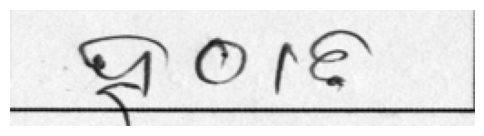

Pred: ହୁରାିଟ
True: ହଠାତ
----------------------------------------


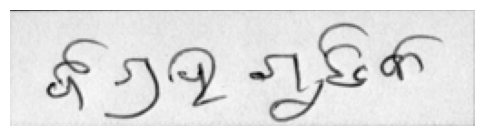

Pred: ବ୍ର୍ମରତିିି
True: ବିଗ୍ରହଗୁଡିକ
----------------------------------------


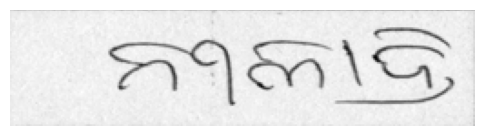

Pred: ନନତିତି
True: ନୀଳାଦ୍ରି
----------------------------------------


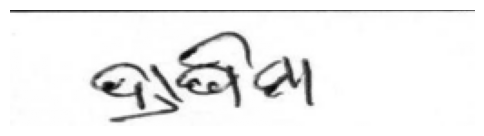

Pred: ସ୍ର୍ୟ
True: ଦ୍ରାଘିମା
----------------------------------------


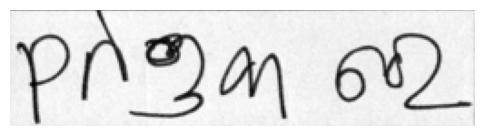

Pred: ମମ୍ମରର
True: ୧୯୭୩ରେ
----------------------------------------


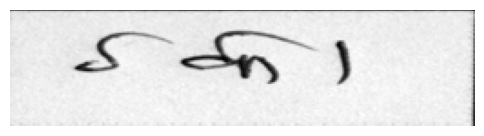

Pred: କନାା
True: ଚକା
----------------------------------------


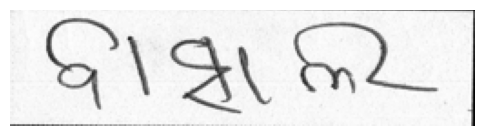

Pred: ବାହାର
True: ବାସାଲ
----------------------------------------


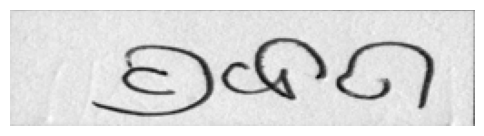

Pred: ପ୍ର୍ର
True: ପ୍ରବଣ
----------------------------------------


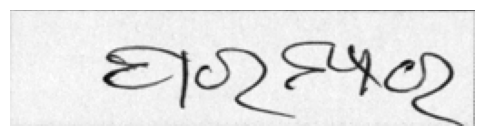

Pred: ପରର
True: ପରମ୍ପର
----------------------------------------


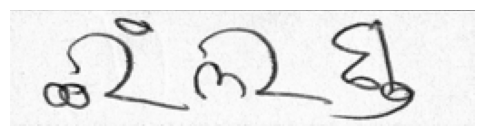

Pred: ସର୍ଣ୍ତ
True: ଇଂଲଣ୍ଡ
----------------------------------------


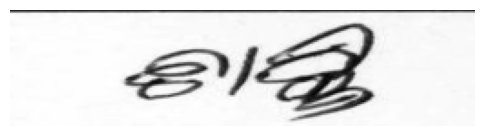

Pred: ଜଙି
True: ଶକ୍ତି
----------------------------------------


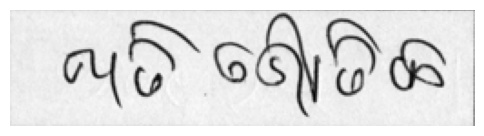

Pred: ଆିରିକ
True: ଅତିଭୌତିକ
----------------------------------------


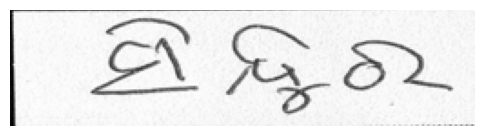

Pred: ସିରିର
True: ସିନ୍ଦୁର
----------------------------------------


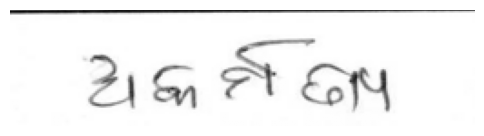

Pred: ମରଦୟ
True: ଅକର୍ମଣ୍ୟ
----------------------------------------


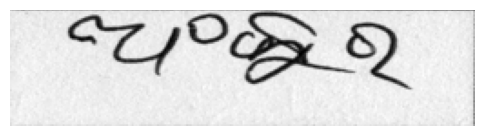

Pred: ଜେଟର
True: ଅଂକୁର
----------------------------------------


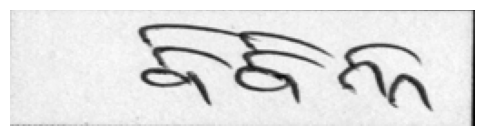

Pred: ବିଞିିନ
True: ବିବିନ୍ନ
----------------------------------------


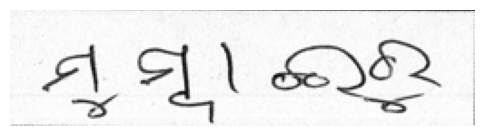

Pred: ସୁମାକରୁ
True: ମୁମ୍ବାଇରୁ
----------------------------------------


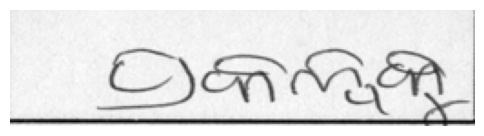

Pred: ପ୍ର୍ରୁ
True: ପ୍ରକଳ୍ପକୁ
----------------------------------------


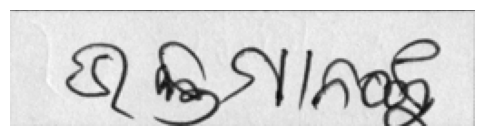

Pred: ପର୍ମମାମଙ୍କୁ
True: ଭକ୍ତମାନଙ୍କୁ
----------------------------------------


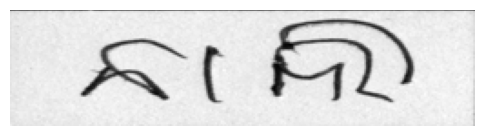

Pred: କାନିିି
True: ନାଲି
----------------------------------------


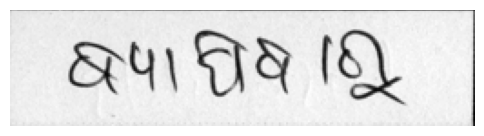

Pred: ଗାରାାରୁ
True: ବ୍ୟାପିବାରୁ
----------------------------------------


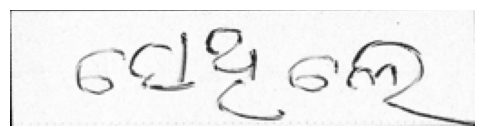

Pred: ପରଲେ
True: ସେଥିଲେ
----------------------------------------


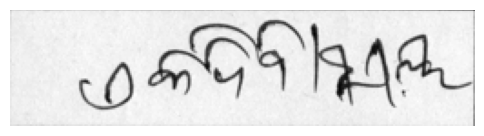

Pred: ସରଦିବିଥର
True: ଏକଦିବାସୀୟ
----------------------------------------


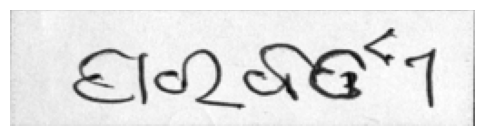

Pred: ସରମୀ
True: ପରବର୍ତୀ
----------------------------------------


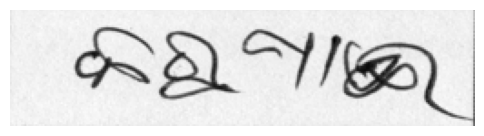

Pred: କତର
True: କରୁଥାଇ
----------------------------------------


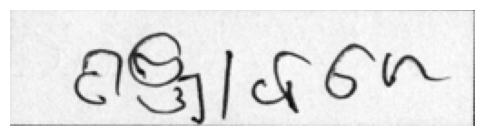

Pred: ପ୍ର୍ବାରେ
True: ପଞ୍ଜାବରେ
----------------------------------------


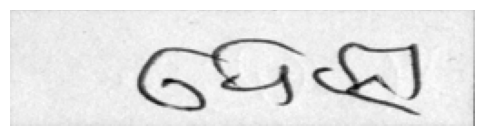

Pred: ଦେଦସ
True: ଦେଖୁ
----------------------------------------


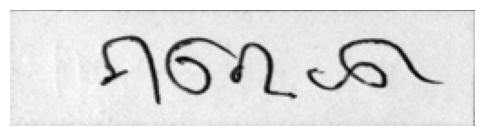

Pred: ମାଲତ
True: ମରେଇ
----------------------------------------


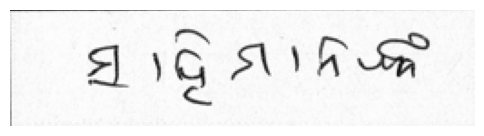

Pred: ପରାହାଙ୍କ
True: ସାହିମାନଙ୍କ
----------------------------------------


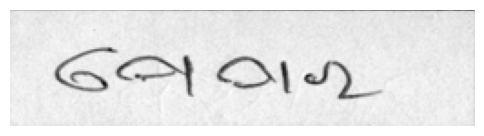

Pred: ପପର
True: ପେପର
----------------------------------------


In [37]:
pred = model.predict(X_test)

pred_indices = np.argmax(pred, axis=-1)

for i in range(30):

    pred_text = decode_prediction(pred_indices[i])
    true_text = decode_label(y_test[i])

    plt.figure(figsize=(6,2))
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.show()

    print("Pred:", pred_text)
    print("True:", true_text)
    print("-"*40)